In [1]:
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

In [10]:
# clear the model predictions csv
with open('DecisionTreeResult.csv', 'w') as file:
    file.write('')

In [11]:
# Load the filtered dataset
data = pd.read_csv('../../Feature Engineering/customer_profit_status.csv')

In [12]:
# Define features and target
X = data[['CustomerTier', 'PercentProfit']]
y = data['QuoteStatus']

In [13]:
# Encode the target variable 'QuoteStatus' as it is categorical
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [14]:
# Apply SMOTE before splitting to balance the 'Not Converted' class in the entire dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y_encoded)

In [15]:
# Now split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [16]:
# Initialize the Decision Tree model
clf = DecisionTreeClassifier(random_state=42)

In [17]:
# Train the model on the resampled training data
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
# Make predictions on the test set
y_pred = clf.predict(X_test)

In [19]:
# Get confidence percentages (probabilities of predictions)
y_prob = clf.predict_proba(X_test)
confidence = np.max(y_prob, axis=1) * 100  # Convert to percentage

In [20]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.77


In [21]:
# Detailed classification report
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

        Lost       0.78      0.76      0.77     17481
         Won       0.77      0.78      0.78     17334

    accuracy                           0.77     34815
   macro avg       0.77      0.77      0.77     34815
weighted avg       0.77      0.77      0.77     34815



In [22]:
# Prepare the output data for CSV
output_data = X_test.copy()
output_data['Actual Status'] = label_encoder.inverse_transform(y_test)
output_data['Predicted Status'] = label_encoder.inverse_transform(y_pred)
output_data['Confidence (%)'] = confidence

In [24]:
# Save to CSV
output_data.to_csv('DecisionTreeResult.csv', index=False)
print("Predictions have been saved to 'DecisionTreeResult.csv'")

Predictions have been saved to 'DecisionTreeResult.csv'


## Visual analysis of the Decision tree results

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [28]:
data = pd.read_csv('DecisionTreeResult.csv')

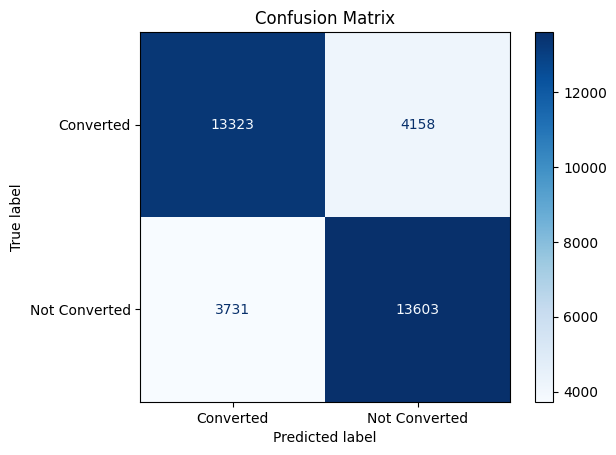

In [29]:
# Confusion Matrix
cm = confusion_matrix(data['Actual Status'], data['Predicted Status'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Converted', 'Not Converted'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


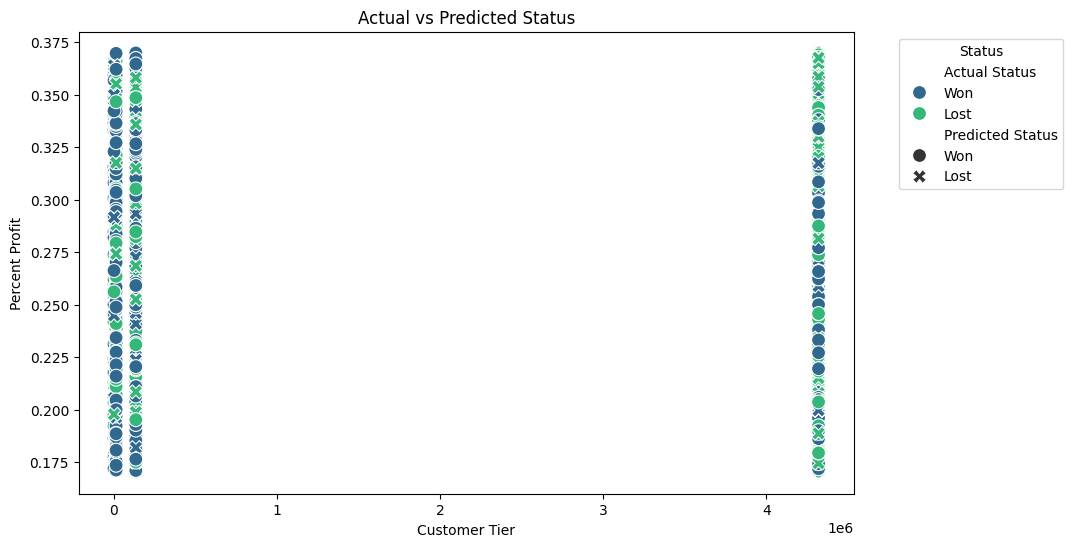

In [30]:
# Scatter Plot of Features (CustomerTier vs PercentProfit)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='CustomerTier', y='PercentProfit', hue='Actual Status', style='Predicted Status',
    data=data, palette='viridis', markers=['o', 'X'], s=100
)
plt.title('Actual vs Predicted Status')
plt.xlabel('Customer Tier')
plt.ylabel('Percent Profit')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

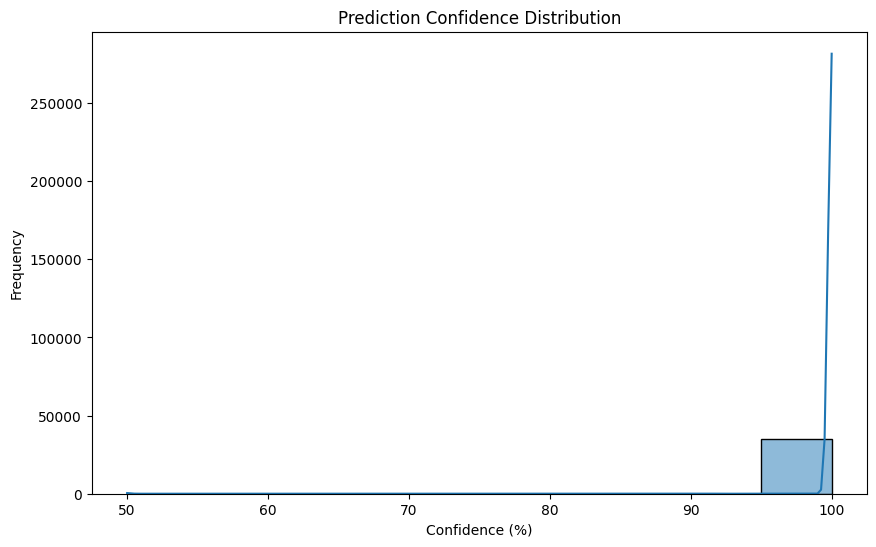

In [31]:
# Histogram of Confidence Percentages
plt.figure(figsize=(10, 6))
sns.histplot(data['Confidence (%)'], bins=10, kde=True)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Confidence (%)')
plt.ylabel('Frequency')
plt.show()